# PyTorch Convolutional Neural Network (CNN) With CIFAR-10 Color Image Dataset

In this example, we demonstrate how to train a CNN model (aka ConvNet)  to classify images from the CIFAR-10 dataset. With the nature of CNN can handle spatial data of images and video, the RGB-color images  of CIFAR-10 can be directly use as input to the model.

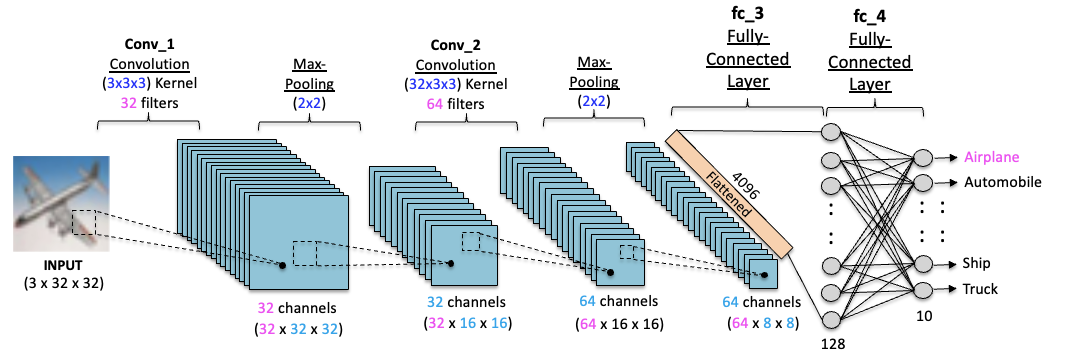

The CIFAR-10 dataset is a widely used collection of images that is commonly used to train machine learning and computer vision algorithms

It consists of 60,000 32x32 color images in 10 different classes
Each class contains 6,000 images, with 5,000 images for training and 1,000 images for testing
The 10 different classes in the CIFAR-10 dataset represent airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks
The CIFAR-10 dataset can be split into training set, validation set, and test set in various ways. In this example, the way is to use 45,000 images for training, 5,000 images for validation, and 10,000 images for testing.

References:

https://github.com/nestorojeda/CIFAR-10-CNN

## Assignment 2: Summary Report

Provide your assignment report here. Write a summary report of your model architecture design, training process, experimental results, evaluation, and conclusions. Discuss which techniques work well and how you could improve the baseline model. Include relevant visualizations.

.....

.....

.....

In [1]:
# Install the torchinfo package for showing the network architecture information
!pip install torchinfo -qqq

In [2]:
# Import the necessary libraries for working with CIFAR-10 dataset and PyTorch.
import warnings
import logging

# Suppress occasional InDuctor warning for small GPUs about max_autotune_gemm.
# This warning is harmless and does not affect training.
warnings.filterwarnings(
    "ignore",
    message=r".*max_autotune_gemm.*",
    category=UserWarning,
)
# The warning is emitted via the torch._inductor.utils logger.
logging.getLogger("torch._inductor.utils").setLevel(logging.ERROR)
logging.getLogger("torch._inductor").setLevel(logging.ERROR)

import torch
import torchvision
from torchvision import datasets, transforms

# We use timm's ConvNeXt V2 implementation exclusively.
import timm  # type: ignore[import]

import torch.nn as nn
from torch import optim

from torchinfo import summary

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import sys
import time
import copy

In [3]:
# To configure the usage of a GPU (cuda) or MPS (Apple) if either of them is available
has_mps = torch.backends.mps.is_available()
device = "cuda" if torch.cuda.is_available() else "mps" if has_mps else "cpu"

# Strict CUDA OOM mode: cap VRAM and fail fast instead of spilling to system memory
STRICT_CUDA_OOM = True
CUDA_MEMORY_FRACTION = 0.99
if device == "cuda" and STRICT_CUDA_OOM:
    torch.cuda.set_per_process_memory_fraction(CUDA_MEMORY_FRACTION)
    print(f"Strict CUDA OOM mode ON (memory fraction cap: {CUDA_MEMORY_FRACTION:.2f})")

# Enable fast math (TF32) on Ampere+ GPUs
if device == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

print(f"Python version: {sys.version_info.major, sys.version_info.minor, sys.version_info.micro}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

Strict CUDA OOM mode ON (memory fraction cap: 0.99)
Python version: (3, 12, 12)
PyTorch version: 2.12.0.dev20260317+cu130
Device: cuda


In [4]:
# Set seed for reproducibility
seed = 1339
torch.manual_seed(seed)

# Download CIFAR10 Dataset

This piece of code helps in downloading and managing the training and test data for a model. The training dataset used is called CIFAR-10 and it has 50,000 training samples. The test dataset is divided into two parts: a validation set and a test set, each with 5,000 samples. The data loaders help in providing batches of data from these datasets for the model to train on. The training data consists of batches of images, where each image is a 32 x 32 pixel color image. The corresponding labels indicate the correct class for each image, such as airplanes, cars, birds, cats, etc.


In [5]:
# Define the input image size (make images larger than CIFAR default 32x32)
INPUT_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

test_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

# Create the CIFAR10 dataset for the training set with 50,000 images
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)

# Create the CIFAR10 dataset for the test set with 10,000 images
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# Split the original test set into a validation set with 5,000 samples and a test set with 5,000 samples
val_set, test_set = torch.utils.data.random_split(test_dataset, [5000, 5000])

# Define the data loaders for the training, validation, and test sets
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True, num_workers=4, pin_memory=(device == 'cuda'), persistent_workers=True, prefetch_factor=2)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=64, shuffle=False, num_workers=4, pin_memory=(device == 'cuda'), prefetch_factor=2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False, num_workers=4, pin_memory=(device == 'cuda'), prefetch_factor=2)

# Define the classes for the CIFAR-10 dataset
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']




## Visualize image for each class

The first step in a classification task is to take a look at the data, make sure it is loaded in correctly, then make any initial observations about patterns in that data.

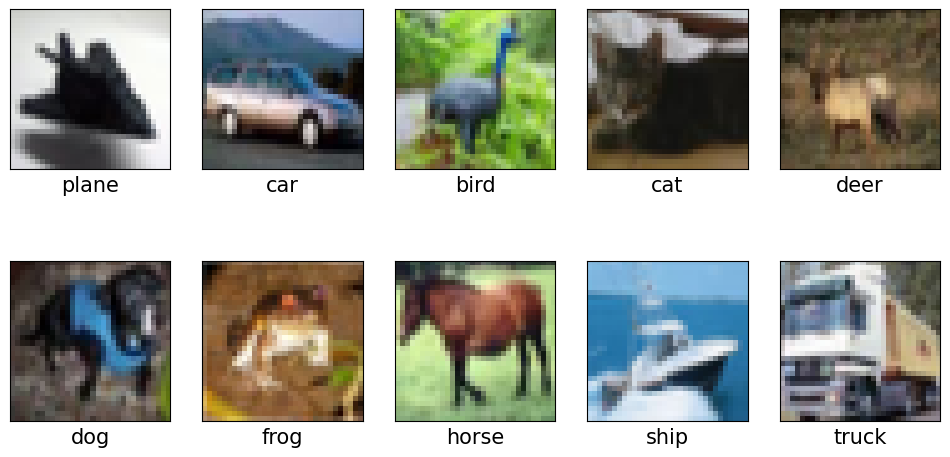

In [6]:
# Visualize training image for each class
sample_images = [train_set.data[np.asarray(train_set.targets) == label][0] for label in range(10)]
# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel(classes[i], fontsize=15)
    axis.imshow(sample_images[i])
    i += 1

## Define the CNN Architecture

The following code defines a class called CNN_Model which inherits from nn.Module. The network has 2 fully-connected layers:

- In the first line, we use the "Conv2d" module to implement a convolutional neural network. The first parameter, 3, indicates that the input image is colored and in RGB format. If it were a grayscale image, we would use 1 instead.

- The number 32 represents the initial output channels, and in the next Conv2d layer, we would use 32 as the input channels and 64 as the output channels.

- The third parameter in the first line is the kernel size, which determines the size of the filters used. The last parameter is for padding, which helps maintain the spatial dimensions of the input.

After each Conv2d layer, we apply an activation function, specifically the Rectified Linear Unit (ReLU). Following two Conv2d layers, we perform a max-pooling operation with a 2x2 size. The resulting values are then batch normalized to ensure stability and avoid internal covariate shift. These operations are repeated with additional layers to make the network deeper and reduce the size of the data. Finally, we flatten the layer to create a linear layer that maps the values to 10 outputs. The probability of each neuron in these 10 outputs determines the class to which a particular image belongs, with the highest probability indicating the predicted class.

In [7]:
# Define the ConvNeXt model (uses ImageNet-style stem for 224×224 inputs)
# Uses timm's ConvNeXt V2 implementation with pretrained ImageNet weights.

def build_convnext_cifar10(num_classes=10):
    # Use timm's ConvNeXt V2 tiny model. `pretrained=True` provides ImageNet weights.
    model = timm.create_model("convnextv2_tiny", pretrained=True, num_classes=num_classes)
    return model

In [8]:
model = build_convnext_cifar10(num_classes=10)

In [9]:
summary(model=model, input_size=(1, 3, INPUT_SIZE, INPUT_SIZE), col_width=15,
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'], verbose=0)

Layer (type (var_name))                                 Input Shape     Output Shape    Param #         Trainable
ConvNeXt (ConvNeXt)                                     [1, 3, 224, 224] [1, 10]         --              True
├─Sequential (stem)                                     [1, 3, 224, 224] [1, 96, 56, 56] --              True
│    └─Conv2d (0)                                       [1, 3, 224, 224] [1, 96, 56, 56] 4,704           True
│    └─LayerNorm2d (1)                                  [1, 96, 56, 56] [1, 96, 56, 56] 192             True
├─Sequential (stages)                                   [1, 96, 56, 56] [1, 768, 7, 7]  --              True
│    └─ConvNeXtStage (0)                                [1, 96, 56, 56] [1, 96, 56, 56] --              True
│    │    └─Identity (downsample)                       [1, 96, 56, 56] [1, 96, 56, 56] --              --
│    │    └─Sequential (blocks)                         [1, 96, 56, 56] [1, 96, 56, 56] 239,904         True
│    └─ConvNe

## Training the Network

The steps for training/learning from a batch of data are described in the comments below:

Clear the gradients of all optimized variables
Forward pass: compute predicted outputs by passing inputs to the model
Calculate the loss
Backward pass: compute gradient of the loss with respect to model parameters
Perform a single optimization step (parameter update)
Update average training loss
The following loop trains for 50 epochs; take a look at how the values for the training loss decrease over time. We want it to decrease while also avoiding overfitting the training data.

In [10]:
# Create a Models folder to store the checkpoints
!mkdir Models

## Specify Loss Function and Optimizer
It's recommended that you use cross-entropy loss for classification. If you look at the documentation (linked above), you can see that PyTorch's cross entropy function applies a softmax funtion to the output layer and then calculates the log loss.

In [11]:
EPOCHS = 5

criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
criterion_soft = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-5, betas=(0.9, 0.999))

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS * len(train_loader), eta_min=0.8e-4)

# Track LR history for diagnostics
lr_history = []

# AMP (enabled on CUDA) for faster training
amp_enabled = (device == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=amp_enabled)



In [12]:
loss_hist, acc_hist = [], []
loss_hist_val, acc_hist_val = [], []

# Move model to device (and use channels_last for faster convolution kernels on CUDA)
if device == "cuda":
    model = model.to(device=device, memory_format=torch.channels_last)
else:
    model = model.to(device)

# Compile the model.
if hasattr(torch, "compile"):
    model = torch.compile(model, mode="reduce-overhead")

# EMA (Exponential Moving Average) for smoother evaluation weights
ema_decay = 0.999
ema_model = copy.deepcopy(model)
for p in ema_model.parameters():
    p.requires_grad_(False)

# Track the best validation accuracy for checkpointing
best_val_acc = 0.0
best_epoch = 0

print("Training was started.\n")

for epoch in range(1, EPOCHS + 1):
    time_ckpt = time.time()
    print("EPOCH:", epoch, end=" ")

    model.train()
    running_loss = 0.0
    train_seen = 0
    correct = 0

    for batch, labels in train_loader:
        batch = batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        labels_for_acc = labels

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type='cuda', enabled=amp_enabled):
            outputs = model(batch)
            if labels.ndim == 2:
                loss = criterion_soft(outputs, labels)
            else:
                loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # For AMP, only advance scheduler when optimizer step actually happened.
        # If gradients overflow, GradScaler lowers the scale and skips optimizer.step().
        scale_before = scaler.get_scale() if amp_enabled else None

        scaler.step(optimizer)
        scaler.update()

        optimizer_step_ran = (not amp_enabled) or (scaler.get_scale() >= scale_before)
        if optimizer_step_ran:
            scheduler.step()
            lr_history.append(optimizer.param_groups[0]['lr'])

            # Update EMA weights (for stable evaluation)
            with torch.no_grad():
                for ema_p, p in zip(ema_model.parameters(), model.parameters()):
                    ema_p.mul_(ema_decay).add_(p, alpha=1.0 - ema_decay)

        # compute training statistics
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels_for_acc).sum().item()

        batch_size = labels_for_acc.size(0)
        running_loss += loss.item() * batch_size
        train_seen += batch_size

    avg_loss = running_loss / train_seen
    avg_acc = correct / train_seen
    loss_hist.append(avg_loss)
    acc_hist.append(avg_acc)

    # validation statistics
    model.eval()
    with torch.no_grad():
        loss_val = 0.0
        correct_val = 0
        val_seen = 0

        for batch, labels in val_loader:
            batch = batch.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.autocast(device_type='cuda', enabled=amp_enabled):
                outputs = ema_model(batch)
                loss = criterion(outputs, labels)

            _, predicted = torch.max(outputs, 1)
            correct_val += (predicted == labels).sum().item()

            batch_size = labels.size(0)
            loss_val += loss.item() * batch_size
            val_seen += batch_size

        avg_loss_val = loss_val / val_seen
        avg_acc_val = correct_val / val_seen
        loss_hist_val.append(avg_loss_val)
        acc_hist_val.append(avg_acc_val)

    # Scheduler is stepped per batch here, so no per-epoch step is required.

    # Save per-epoch checkpoint
    torch.save(model.state_dict(), f"Models/convnext_model_{epoch}.pth")

    # Save best checkpoint (based on validation accuracy)
    is_new_best = avg_acc_val > best_val_acc
    if is_new_best:
        best_val_acc = avg_acc_val
        best_epoch = epoch
        # Save both the raw model weights and the EMA weights to avoid mismatch
        torch.save(model.state_dict(), "Models/convnext_model_best.pth")
        torch.save(ema_model.state_dict(), "Models/convnext_model_best_ema.pth")

    print("LR: {:.6f}".format(optimizer.param_groups[0]['lr']), end=" ")
    print("Training Loss: {:.4f}".format(avg_loss), end=" ")
    print("Val Loss: {:.4f}".format(avg_loss_val), end=" ")
    print("Train Accuracy: {:.2f}%".format(avg_acc * 100), end=" ")
    print("Val Accuracy: {:.2f}%".format(avg_acc_val * 100), end=" ")
    print("Time: {:.2f}s".format(time.time() - time_ckpt), end="")
    if is_new_best:
        print(" Best!", end="")
    print()


Training was started.

EPOCH: 1 LR: 0.000098 Training Loss: 0.2655 Val Loss: 0.3308 Train Accuracy: 95.44% Val Accuracy: 97.94% Time: 318.18s Best!
EPOCH: 2 LR: 0.000093 Training Loss: 0.1794 Val Loss: 0.1800 Train Accuracy: 98.38% Val Accuracy: 98.60% Time: 176.86s Best!
EPOCH: 3 LR: 0.000087 Training Loss: 0.1570 Val Loss: 0.1710 Train Accuracy: 99.14% Val Accuracy: 98.56% Time: 181.58s
EPOCH: 4 LR: 0.000082 Training Loss: 0.1473 Val Loss: 0.1732 Train Accuracy: 99.43% Val Accuracy: 98.70% Time: 184.41s Best!
EPOCH: 5 LR: 0.000080 Training Loss: 0.1417 Val Loss: 0.1773 Train Accuracy: 99.62% Val Accuracy: 98.56% Time: 187.47s


## Learning Rate Schedule

The plot below shows the learning rate used at each optimizer step (recorded in `lr_history`).

A smooth cosine decay schedule helps stabilize training and often leads to better final performance compared to a fixed or step-decay learning rate.

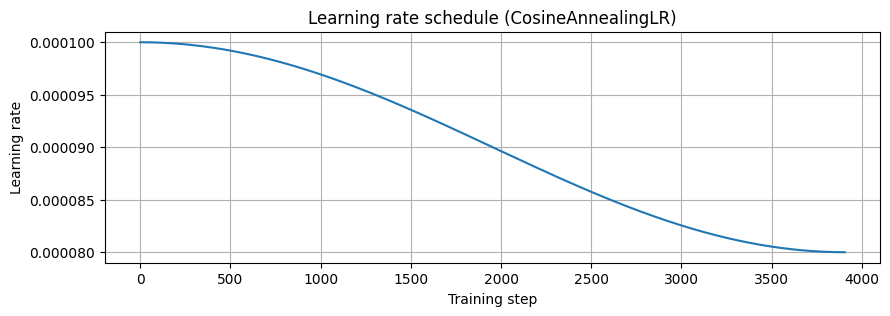

In [13]:
plt.figure(figsize=(10, 3))
plt.plot(lr_history)
plt.title("Learning rate schedule (CosineAnnealingLR)")
plt.xlabel("Training step")
plt.ylabel("Learning rate")
plt.grid(True)
plt.show()

## Plotting Training Statistics

Loss is a function of the difference of the network output and the target values. We are minimizing the loss function during training so it should decrease over time. Accuracy is the classification accuracy for the test data.

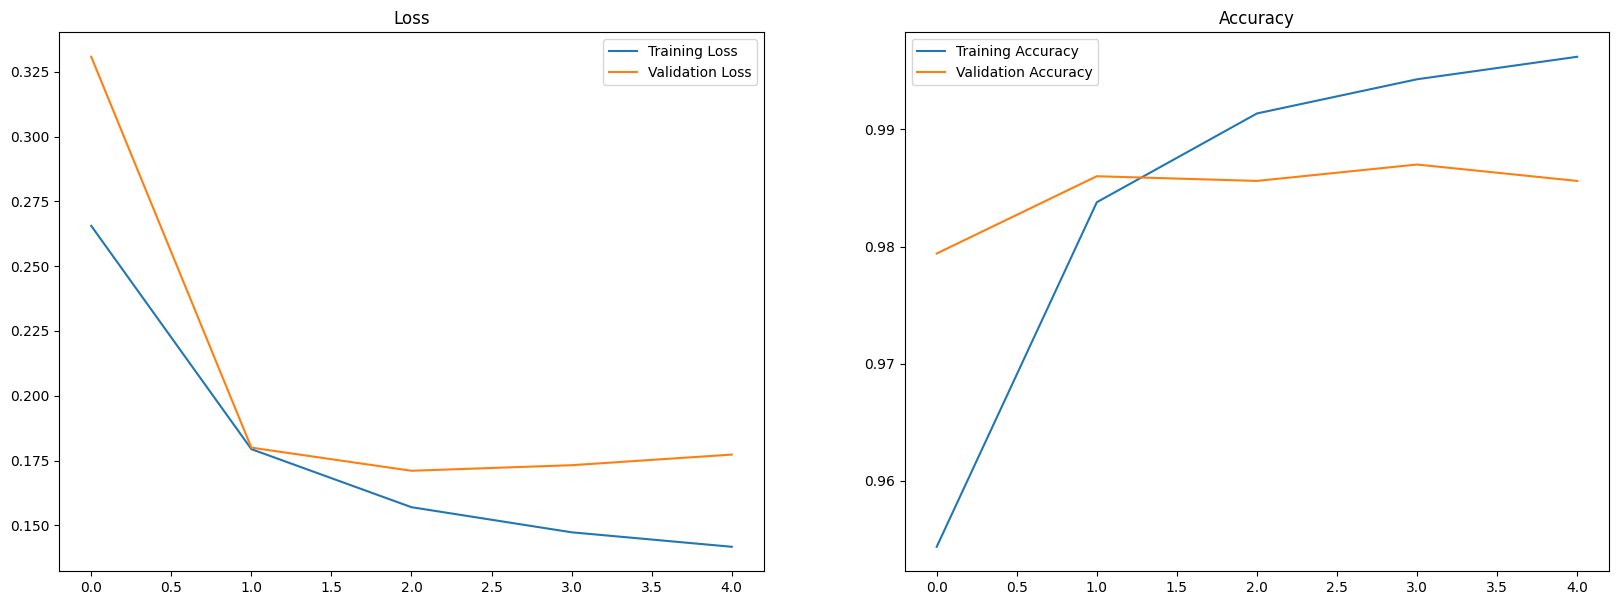

In [14]:
plots=[(loss_hist,loss_hist_val),(acc_hist,acc_hist_val)]
plt_labels=[("Training Loss","Validation Loss"),("Training Accuracy","Validation Accuracy")]
plt_titles=["Loss","Accuracy"]
plt.figure(figsize=(20,7))
for i in range(0,2):
    ax=plt.subplot(1,2,i+1)
    ax.plot(plots[i][0],label=plt_labels[i][0])
    ax.plot(plots[i][1],label=plt_labels[i][1])
    ax.set_title(plt_titles[i])
    ax.legend()

## Save Trained Model Weights

In [15]:
# from google.colab import files
# torch.save(model.state_dict(), 'checkpoint.pth')
# # download checkpoint file
# files.download('checkpoint.pth')
# model.load_state_dict(torch.load('checkpoint.pth'))

In [16]:
# Selecting the best model
best_acc = max(acc_hist_val)
best_epoch = acc_hist_val.index(best_acc) + 1

print("Best accuracy on validation set: {:.2f}%".format(best_acc * 100))
print("Best epoch: {}".format(best_epoch))

# Load the best checkpoint (saved by validation accuracy)
model.load_state_dict(torch.load("Models/convnext_model_best.pth", map_location=device))
# Load the EMA checkpoint separately so evaluation uses the same weights that were saved
ema_model.load_state_dict(torch.load("Models/convnext_model_best_ema.pth", map_location=device))

model.to(device)
model.eval()
ema_model.to(device)
ema_model.eval();

Best accuracy on validation set: 98.70%
Best epoch: 4


# Test the Trained Network
Finally, we test our best model on previously unseen test data and evaluate it's performance. Testing on unseen data is a good way to check that our model generalizes well. It may also be useful to be granular in this analysis and take a look at how this model performs on each class as well as looking at its overall loss and accuracy.

In [17]:
pred_vec = []
label_vec = []
correct = 0
test_loss = 0.0

model.to(device)
model.eval()

with torch.no_grad():
    seen = 0
    for batch, labels in test_loader:
        batch = batch.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type='cuda', enabled=amp_enabled):
            outputs = ema_model(batch)
            loss = criterion(outputs, labels)

        _, predicted = torch.max(outputs, 1)

        batch_size = labels.size(0)
        test_loss += loss.item() * batch_size
        correct += (predicted == labels).sum().item()
        seen += batch_size

        pred_vec.extend(predicted.cpu().numpy())
        label_vec.extend(labels.cpu().numpy())

    avg_test_loss = test_loss / seen

pred_vec = np.array(pred_vec)
label_vec = np.array(label_vec)


## Display Test Set Accuracy

In [18]:
print(F"Test Loss: {avg_test_loss}")
print(F"Test Accuracy on the {len(test_set)} test images: {(100 * correct / len(test_set))}%")

Test Loss: 0.17387352969646455
Test Accuracy on the 5000 test images: 98.64%


## Display Confusion Matrix

In [19]:
# Create confusion matrix
from sklearn.metrics import confusion_matrix
confusion_mat = confusion_matrix(label_vec, pred_vec)
# Convert confusion matrix to pandas DataFrame
labels = np.unique(label_vec)
confusion_df = pd.DataFrame(confusion_mat, index=classes, columns=classes)
print("Confusion Matrix")
confusion_df

Confusion Matrix


,plane,car,bird,cat,deer,dog,frog,horse,ship,truck
plane,486,0,0,1,0,0,0,0,4,0
car,0,493,0,0,0,0,0,0,1,3
bird,0,0,499,1,3,1,0,0,1,0
cat,0,0,1,498,1,12,2,0,1,1
deer,0,0,2,1,481,0,1,2,0,0
dog,0,0,0,13,0,494,1,1,0,0
frog,0,0,1,0,0,0,480,0,0,0
horse,0,0,0,1,1,1,0,492,0,0
ship,1,0,0,0,0,0,0,1,521,2
truck,0,6,0,0,0,0,0,0,0,488


# Compute the Accuracy, F1-Score, Precision, Recall, Support

In [20]:
# Create a report to show the f1-score, precision, recall
from sklearn.metrics import classification_report

report = pd.DataFrame.from_dict(classification_report(pred_vec,label_vec,output_dict=True)).T
report['Label']=[classes[int(x)] if x.isdigit() else " " for x in report.index]
report=report[['Label','f1-score','precision','recall','support']]
report

,Label,f1-score,precision,recall,support
0,plane,0.993865,0.989817,0.997947,487.0000
1,car,0.989960,0.991952,0.987976,499.0000
2,bird,0.990079,0.988119,0.992048,503.0000
3,cat,0.966052,0.965116,0.966990,515.0000
4,deer,0.988695,0.987680,0.989712,486.0000
5,dog,0.971485,0.970530,0.972441,508.0000
6,frog,0.994819,0.997921,0.991736,484.0000
7,horse,0.992936,0.993939,0.991935,496.0000
8,ship,0.989554,0.992381,0.986742,528.0000
9,truck,0.987854,0.987854,0.987854,494.0000


In the context of classification, 'support' refers to the number of instances or samples in a dataset that belong to a specific class. It represents the frequency or count of occurrences of each class in the dataset.

Support values help assess the reliability and generalizability of classification models, as they indicate the amount of data available for each class and the potential challenges associated with imbalanced datasets.

# Visualize Sample Test Results
This cell displays test images and their labels in this format: predicted (ground-truth). The text will be green for accurately classified examples and red for incorrect predictions.

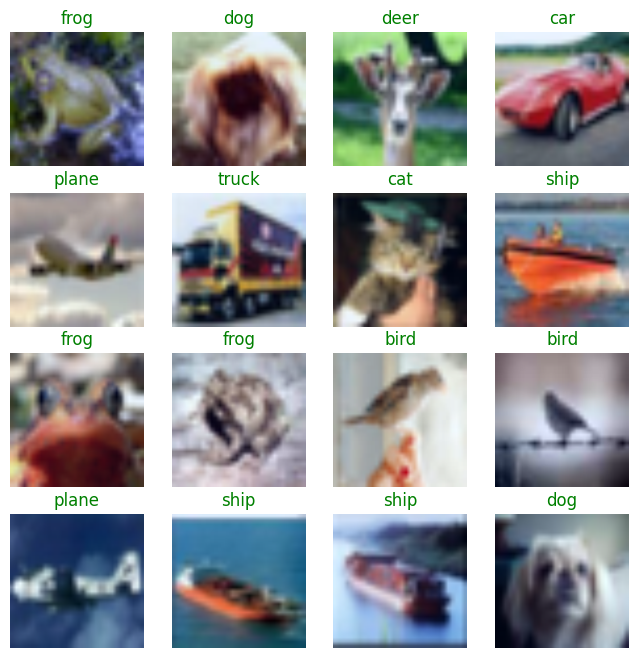

In [21]:
# obtain one batch of test images
images, labels = next(iter(test_loader))
model.to(device)
model.eval()

images_device = images.to(device)
with torch.no_grad():
    output = model(images_device)

# convert output probabilities to predicted class
_, preds = torch.max(output, 1)
preds = preds.cpu()

# Create a 4x4 grid for displaying the images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

# Iterate over the images and display them in the grid
for idx, ax in enumerate(axes.flat):
    # Normalize the image tensor to [0, 1] range
    image = images[idx].permute(1, 2, 0)
    image = (image - image.min()) / (image.max() - image.min())
    ax.imshow(image)  # Display the image
    ax.axis('off')  # Hide the axes
    ax.set_title(
        "{}".format(classes[preds[idx]]),
        color=("green" if preds[idx] == labels[idx] else "red"),
    )
plt.show()

#Display 50 Predicted Images
We iterate through 50 images and plot them with their corresponding label. We will color the label in blue if our model guessed correct and in red if it failed to predict that class.

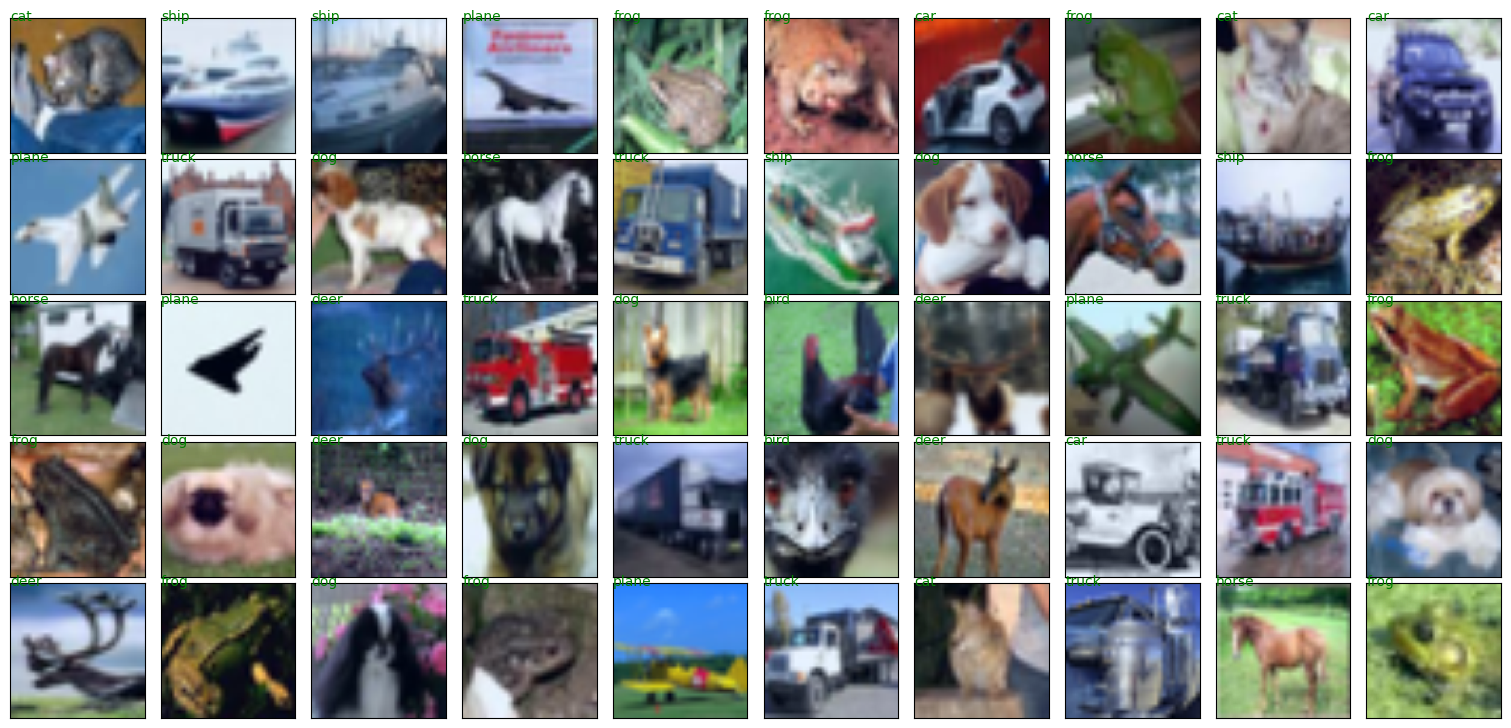

In [22]:
# Define the loader for all test data
test_set_all = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=test_transform)
test_loader_all = torch.utils.data.DataLoader(test_set_all, batch_size=128, shuffle=False, num_workers=2)


# obtain one batch of test images
images, labels = next(iter(test_loader_all))
model.to(device)
images = images.to(device)

# get sample outputs
output = ema_model(images)
# convert output probabilities to predicted class
_, preds = torch.max(output, 1)


fig = plt.figure(figsize=(15, 7))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

for idx in range(50):
    # Normalize the image tensor to [0, 1] range
    image = images[idx].permute(1, 2, 0).cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min())
    ax = fig.add_subplot(5, 10, idx + 1, xticks=[], yticks=[])
    ax.imshow(image, interpolation='nearest')

    if preds[idx]==labels[idx]:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='green')
    else:
      ax.text(0, 3, str(classes[preds[idx].item()]), color='red')

plt.show()


## Visualize wrongly classified image for each class

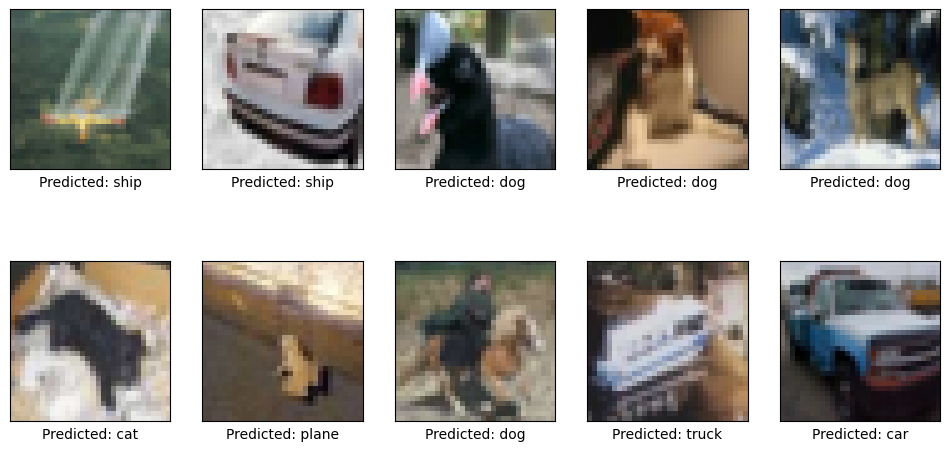

In [23]:
# Visualize wrongly classified image for each class
pred_vec_all = []
correct = 0
test_loss = 0.0

model.to(device)

with torch.no_grad():
    for data in test_loader_all:
        batch, labels = data
        batch, labels = batch.to(device), labels.to(device)
        outputs = ema_model(batch)
        test_loss=criterion(outputs, labels)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        pred_vec_all.append(predicted)
    pred_vec_all = torch.cat(pred_vec_all)

pred_vec_all = pred_vec_all.cpu().numpy()
ground_truths = np.asarray(test_set_all.targets)
incorrect_mask = pred_vec_all != ground_truths
incorrect_images = [test_set_all.data[(ground_truths == label) & incorrect_mask][0] for label in range(10)]
pred_results_all = [pred_vec_all[(ground_truths == label) & incorrect_mask][0] for label in range(10)]

# show images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
i = 0
for row in axes:
  for axis in row:
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_xlabel("Predicted: %s" % classes[pred_results_all[i]], fontsize=10)
    axis.imshow(incorrect_images[i], cmap='gray')
    i += 1